# Summary on using VAEs to compress short time-series

Author: Zhengqing Zhou
Updated: 2026/06/16

In this notebook, we recall the models trained on each gLV model with sparse time series data at different latent dimensions, and quantify the essential dimensionality for reconstructing n_target population dynamics

> ### Reproducibility &amp; data
>
> This notebook reproduces the short/sparse-series FUV / Eᴄ figures from the in-repo `saved_data/` caches. Reloading models needs Zenodo; raw sims come from `../VAE_gLV_simulation/`.
>
> Notebook **outputs are preserved**, so the results are visible without rerunning. Figure-saving (`savefig`) is disabled for the release; plots still render inline. See the repository `DATA.md` for how to restore Zenodo artifacts.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import trange
from torch.nn import functional as F
from torch import nn

from sklearn.metrics import r2_score

from VAE_model import VAE

# Configure GPU if available
if torch.cuda.is_available():

    device = "cuda:0"
else:
    device = "cpu"

display(device)

'cuda:0'

# Effective dimension of short observable time series

We define a function `get_error` which will return the MSE loss of the reconstruction of a `n_target` populations using an `n_embedding` dimensional VAE model. By iterating through all the parameters, we can then determine the essential dimensionality for the reconstruction of a given size target population dynamics.

We define a variable `n_obs` as the number of timepoints being measured in each dataset. The rest of the data are either zero-padded, or linearly interpolated between the known time points.


In [2]:
def get_error(model,batch,time_index):
    model.to("cuda:0");
    model.eval()
    with torch.no_grad():
        reconstruction,_,mu,log_var = model(batch.to("cuda:0"))
        reconstruction = reconstruction.cpu()
        mse = F.mse_loss(batch[:,:,time_index],reconstruction[:,:,time_index])
        r2 = r2_score(batch[:,:,time_index].flatten(), reconstruction[:,:,time_index].flatten())
        kld = (-0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp()))
    return mse,kld,r2

In [3]:
def get_data(n_target, sim_type, model_index):
    n_background = int(100 - n_target)
    X_train = np.load(f"../VAE_gLV_simulation/saved_sims/bgLV/I{model_index}/"
                      f"bgLV_B{n_background}_T{n_target}_{sim_type}_train.npy")
    X_test = np.load(f"../VAE_gLV_simulation/saved_sims/bgLV/I{model_index}/"
                     f"bgLV_B{n_background}_T{n_target}_{sim_type}_test.npy")

    return X_train, X_test

# ── Preprocessing for short time series ────────────────────────────────────────────────────────
def truncate_and_pad(X, n_obs, T=50):
    X_out = np.zeros_like(X)
    X_out[:, :, :n_obs] = X[:, :, :n_obs]
    return X_out

def subsample_and_interpolate(X, n_obs, T=50, seed=42):
    rng    = np.random.default_rng(seed)
    t_full = np.arange(T)
    # ONE fixed set of timepoints for ALL samples — matches train_sparse.py
    t_sparse = np.sort(rng.choice(T, size=n_obs, replace=False))
    X_out  = np.zeros_like(X)
    for i in range(X.shape[0]):
        for ch in range(X.shape[1]):
            X_out[i, ch, :] = np.interp(t_full, t_sparse, X[i, ch, t_sparse])
    return X_out,t_sparse

# truncated dataset
time points after `n_obs` are zero-padded.

> ⚠️ **Requires Zenodo artifacts.** The cell(s) below reload trained models (`torch.load` / `load_state_dict`) or heavy arrays. To reproduce the published figure *without* a download, skip to the plotting cells that read the in-repo `.txt` caches. Restore artifacts first with `zenodo/zenodo_download.sh` (see `DATA.md`).

In [ ]:
NT=np.array([2,3,5,8,10])
n_obs = 20 #5, 10, 20
time_index = torch.arange(n_obs)

N_EBD = [1, 2, 3, 5, 6, 8, 10, 12, 15, 20, 25, 30, 40, 50]
for model_index in [1, 2, 3]:
    for i,n_target in enumerate(NT):
        n_background = 100-n_target
        data_train = np.zeros((6,len(N_EBD)))
        data_train[0,:] = N_EBD
        data_test = np.zeros((6,len(N_EBD)))
        data_test[0,:] = N_EBD
        X_train, X_test = get_data(n_target, "random", model_index)
        batch_train = truncate_and_pad(X_train, n_obs)
        batch_test = truncate_and_pad(X_test, n_obs)
        batch_train = torch.Tensor(batch_train).float()
        batch_test = torch.Tensor(batch_test).float()
        for trial in range(1,6,1):
            for j,n_embedding in enumerate(N_EBD):
                model = VAE(n_target,n_embedding)
                model.to("cuda:0");
                model.load_state_dict(
                    torch.load(
                        f"./vae_models/bgLV/I{model_index}/truncate/"
                        f"truncate_B{n_background}_T{n_target}_nobs{n_obs}_E{n_embedding}_trial{trial}.pth",
                        weights_only=True)
                )
                mse_train,kld,r2_train=get_error(model,batch_train,time_index)
                data_train[trial,j]=(1-r2_train)*100
                mse_test,kld,r2_test=get_error(model,batch_test,time_index)
                data_test[trial,j]=(1-r2_test)*100
        save_dir = f"./saved_data/I{model_index}"
        os.makedirs(save_dir, exist_ok=True)
        np.savetxt(f"./saved_data/I{model_index}/reconstruction_T{n_target}_nobs{n_obs}_train.txt", data_train)
        np.savetxt(f"./saved_data/I{model_index}/reconstruction_T{n_target}_nobs{n_obs}_test.txt", data_test)
    print(f"model {model_index}, n_obs {n_obs} finished")

model 1, n_obs 20 finished
model 2, n_obs 20 finished
model 3, n_obs 20 finished


Now fit the FUV-embedding relationship to an exponential threshold function

In [5]:
from scipy.optimize import curve_fit
from scipy.stats import t
def y_exp(x,a,b,c):
    yy = -b*(x-a)
    yy[x>a]=0
    y = c*np.exp(yy)
    return y


# Linear model
def linear_model(x, a, b):
    return a * x + b

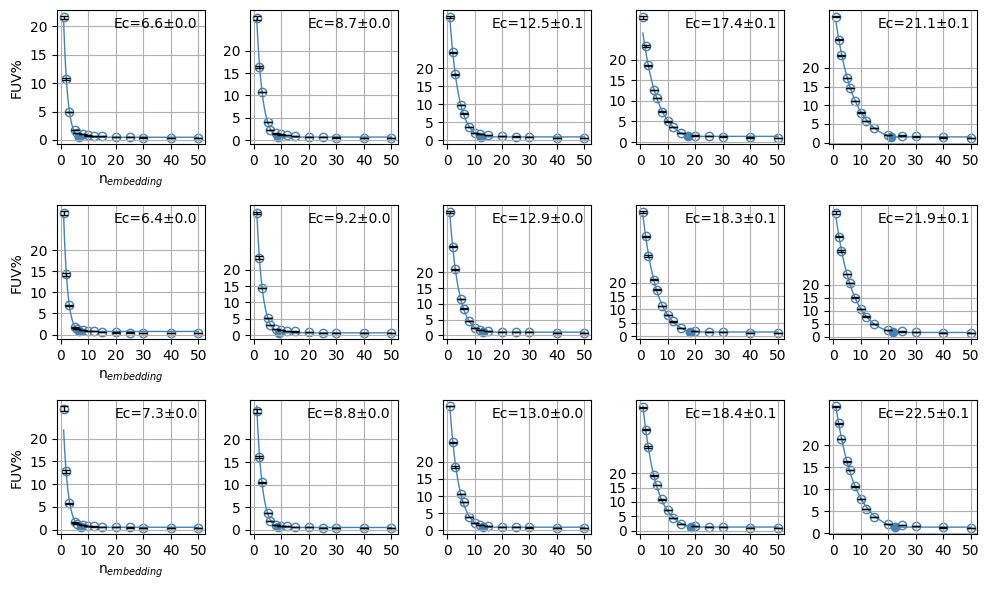

In [28]:
NT=np.array([2,3,5,8,10])
n_obs = 10
n_trial = 5
fig,axes_all=plt.subplots(3,5,figsize=(10,6))
for j, model_index in enumerate([1, 2, 3]):
    axes=axes_all[j,:]
    Ec_data = np.zeros((5,len(NT)))
    Ec_data[0,:]=NT
    for i,n_target in enumerate(NT):
        ax=axes[i]
        data=np.loadtxt(f"./saved_data/I{model_index}/reconstruction_T{n_target}_nobs{n_obs}_test.txt")
        N_EBD=data[0,:]
        FUV = data[1:,:]
        mean_FUV = np.mean(FUV,axis=0)
        std_FUV = np.std(FUV,axis=0,ddof=1)
        se_FUV = std_FUV/np.sqrt(n_trial)
        ax.scatter(N_EBD,mean_FUV,fc='white',ec='steelblue')
        ax.errorbar(N_EBD,mean_FUV,yerr=se_FUV,fmt='none',ecolor='k',elinewidth=1,capsize=3,zorder=10)
        
        popt, pcov = curve_fit(y_exp, N_EBD, mean_FUV, sigma=se_FUV, absolute_sigma=True, p0=(n_target, 0.5, 0.5))
        Ec = popt[0]
        param_errors = np.sqrt(np.diag(pcov))# estimate the standard errors of the fitted parameters
        Ec_se = param_errors[0]
        Ec_data[1,i]=Ec
        Ec_data[2,i]=Ec_se
        y_Ec = y_exp(np.array([Ec]),*popt)
        ax.scatter(Ec,y_Ec,c='steelblue')
        xx=np.linspace(1,50,1000)
        yy=y_exp(xx,*popt)
        ax.plot(xx,yy,color="steelblue",linewidth=1)
        
        ax.text(x=0.95,y=0.95,s="Ec=%1.1f±%1.1f"%(Ec,Ec_se),ha="right",va="top",transform=ax.transAxes)
        if i==0:
            ax.set_xlabel("n$_{embedding}$")
            ax.set_ylabel("FUV%")
        ax.set_xticks(np.arange(0,51,10))
        ax.set_yticks(np.arange(0,21,5))
        ax.grid(True)
    np.savetxt(f"./saved_data/Ec_truncate_model{model_index}_nobs{n_obs}.txt",Ec_data)
fig.tight_layout()

truncated case, n_obs=5
Slope            : 1.113 ± 0.011 (SE)
Intercept        : 4.880 ± 0.067 (SE)
t-statistic      : 105.75  (dof = 3)
p-value (slope≠0): 1.86e-06
Weighted R²      : 0.928
truncated case, n_obs=5
Slope            : 1.416 ± 0.009 (SE)
Intercept        : 2.899 ± 0.048 (SE)
t-statistic      : 159.70  (dof = 3)
p-value (slope≠0): 5.41e-07
Weighted R²      : 0.900
truncated case, n_obs=5
Slope            : 1.278 ± 0.008 (SE)
Intercept        : 4.329 ± 0.054 (SE)
t-statistic      : 158.51  (dof = 3)
p-value (slope≠0): 5.54e-07
Weighted R²      : 0.994


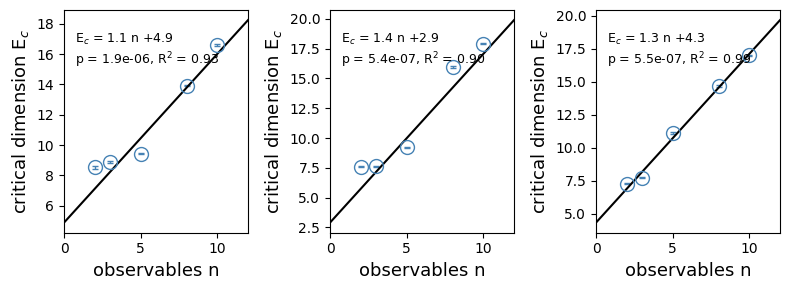

In [ ]:
n_obs = 5
fig,axes= plt.subplots(1,3,figsize=(8,3))
for j,model_index in enumerate([1, 2, 3]):
    ax = axes[j]
    data = np.loadtxt(f"./saved_data/Ec_truncate_model{model_index}_nobs{n_obs}.txt")
    # Extract x, y, and CI bounds
    N_TG = data[0,:]
    Ec = data[1,:]
    Ec_se = data[2,:]
    ax.errorbar(N_TG,Ec,Ec_se,marker="o",c='steelblue',mfc="None",capsize=2,lw=0,markersize=10,
                    elinewidth=1)

    # Weighted fit using standard errors
    popt, pcov = curve_fit(linear_model, N_TG, Ec, sigma=Ec_se, absolute_sigma=True)
    slope, intercept = popt
    slope_se, intercept_se = np.sqrt(np.diag(pcov))

    # residuals and total sums of squares
    y_pred = linear_model(N_TG, slope, intercept)
    SS_res = np.sum(((Ec - y_pred)/Ec_se)**2)     # weighted residual SS
    SS_tot = np.sum(((Ec - np.average(Ec, weights=1/Ec_se**2))/Ec_se)**2)

    R2 = 1 - SS_res / SS_tot

    # Compute t-statistic and p-value
    dof = len(N_TG) - 2
    t_stat = slope / slope_se
    p_value = 2 * (1 - t.cdf(np.abs(t_stat), df=dof))

    # Generate fit line and CI band
    x_fit = np.linspace(0, 12, 100)
    y_fit = linear_model(x_fit, slope, intercept)

    ax.plot(x_fit,y_fit,c="k")
    ax.set_xlim([0, 12])

    # ----- formatted report ---------------------------------------------------
    print(f"truncated case, n_obs={n_obs}")
    report = (
        f"Slope            : {slope:.3f} ± {slope_se:.3f} (SE)\n"
        f"Intercept        : {intercept:.3f} ± {intercept_se:.3f} (SE)\n"
        f"t-statistic      : {t_stat:.2f}  (dof = {dof})\n"
        f"p-value (slope≠0): {p_value:.3g}\n"
        f"Weighted R²      : {R2:.3f}"
    )

    print(report)

    # Format regression equation
    txt = (f"E$_c$ = {slope:.1f} n {intercept:+.1f}\n"
    f"p = {p_value:.1e}, R$^2$ = {R2:.2f}")
    ax.text(x=0.06, y=0.9, s=txt, va='top',transform=ax.transAxes, fontsize=9)
    ax.set_xlabel("observables n", fontsize=13)
    ax.set_ylabel("critical dimension E$_c$", fontsize=13)
fig.tight_layout()

# subsampled and interpolated dataset
`n_obs` timepoints are randomly subsampled and linearly interpolated to fill the full time series.

In [9]:
NT=np.array([2,3,5,8,10])
n_obs = 20 #5, 10, 20

N_EBD = [1, 2, 3, 5, 6, 8, 10, 12, 15, 20, 25, 30, 40, 50]
for model_index in [1, 2, 3]:
    for i,n_target in enumerate(NT):
        n_background = 100-n_target
        data_train = np.zeros((6,len(N_EBD)))
        data_train[0,:] = N_EBD
        data_test = np.zeros((6,len(N_EBD)))
        data_test[0,:] = N_EBD
        X_train, X_test = get_data(n_target, "random", model_index)
        batch_train,time_index = subsample_and_interpolate(X_train, n_obs)
        batch_test,time_index = subsample_and_interpolate(X_test, n_obs)
        batch_train = torch.Tensor(batch_train).float()
        batch_test = torch.Tensor(batch_test).float()
        for trial in range(1,6,1):
            for j,n_embedding in enumerate(N_EBD):
                model = VAE(n_target,n_embedding)
                model.to("cuda:0");
                model.load_state_dict(
                    torch.load(
                        f"./vae_models/bgLV/I{model_index}/sparse/"
                        f"sparse_B{n_background}_T{n_target}_nobs{n_obs}_E{n_embedding}_trial{trial}.pth",
                        weights_only=True)
                )
                mse_train,kld,r2_train=get_error(model,batch_train,time_index)
                data_train[trial,j]=(1-r2_train)*100
                mse_test,kld,r2_test=get_error(model,batch_test,time_index)
                data_test[trial,j]=(1-r2_test)*100
        save_dir = f"./saved_data/I{model_index}"
        os.makedirs(save_dir, exist_ok=True)
        np.savetxt(f"./saved_data/I{model_index}/sparse_reconstruction_T{n_target}_nobs{n_obs}_train.txt", data_train)
        np.savetxt(f"./saved_data/I{model_index}/sparse_reconstruction_T{n_target}_nobs{n_obs}_test.txt", data_test)
    print(f"model {model_index}, n_obs {n_obs} finished")

model 1, n_obs 20 finished
model 2, n_obs 20 finished
model 3, n_obs 20 finished


Now fit the FUV-embedding relationship to an exponential threshold function

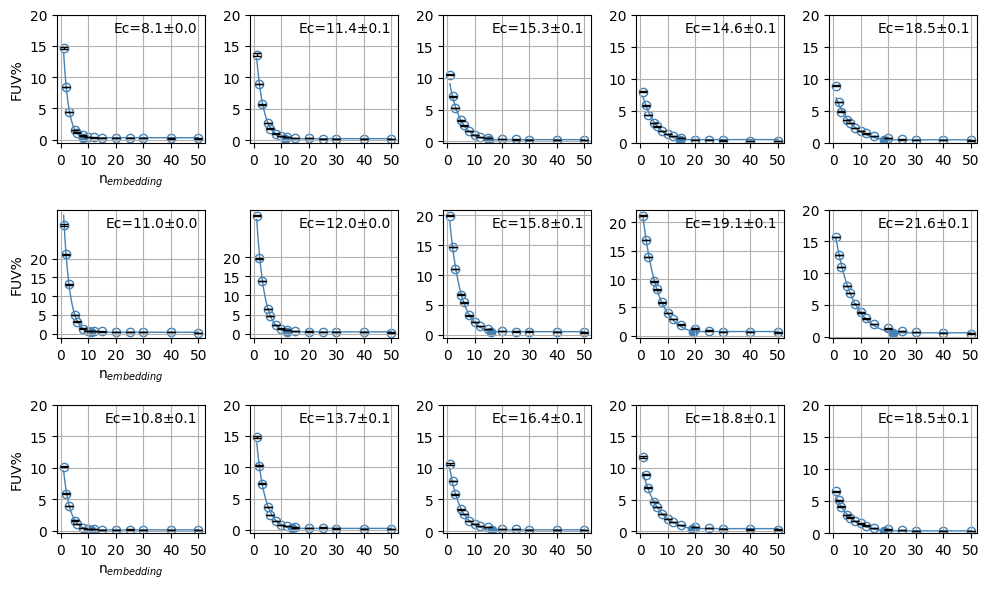

In [12]:
NT=np.array([2,3,5,8,10])
n_obs = 20
n_trial = 5
fig,axes_all=plt.subplots(3,5,figsize=(10,6))
for j, model_index in enumerate([1, 2, 3]):
    axes=axes_all[j,:]
    Ec_data = np.zeros((5,len(NT)))
    Ec_data[0,:]=NT
    for i,n_target in enumerate(NT):
        ax=axes[i]
        data=np.loadtxt(f"./saved_data/I{model_index}/sparse_reconstruction_T{n_target}_nobs{n_obs}_test.txt")
        N_EBD=data[0,:]
        FUV = data[1:,:]
        mean_FUV = np.mean(FUV,axis=0)
        std_FUV = np.std(FUV,axis=0,ddof=1)
        se_FUV = std_FUV/np.sqrt(n_trial)
        ax.scatter(N_EBD,mean_FUV,fc='white',ec='steelblue')
        ax.errorbar(N_EBD,mean_FUV,yerr=se_FUV,fmt='none',ecolor='k',elinewidth=1,capsize=3,zorder=10)
        
        popt, pcov = curve_fit(y_exp, N_EBD, mean_FUV, sigma=se_FUV, absolute_sigma=True, p0=(n_target, 0.5, 0.5))
        Ec = popt[0]
        param_errors = np.sqrt(np.diag(pcov))# estimate the standard errors of the fitted parameters
        Ec_se = param_errors[0]
        Ec_data[1,i]=Ec
        Ec_data[2,i]=Ec_se
        y_Ec = y_exp(np.array([Ec]),*popt)
        ax.scatter(Ec,y_Ec,c='steelblue')
        xx=np.linspace(1,50,1000)
        yy=y_exp(xx,*popt)
        ax.plot(xx,yy,color="steelblue",linewidth=1)
        
        ax.text(x=0.95,y=0.95,s="Ec=%1.1f±%1.1f"%(Ec,Ec_se),ha="right",va="top",transform=ax.transAxes)
        if i==0:
            ax.set_xlabel("n$_{embedding}$")
            ax.set_ylabel("FUV%")
        ax.set_xticks(np.arange(0,51,10))
        ax.set_yticks(np.arange(0,21,5))
        ax.grid(True)
    np.savetxt(f"./saved_data/Ec_sparse_model{model_index}_nobs{n_obs}.txt",Ec_data)
fig.tight_layout()

sparse case, n_obs=20
Slope            : 1.178 ± 0.008 (SE)
Intercept        : 6.405 ± 0.042 (SE)
t-statistic      : 139.62  (dof = 3)
p-value (slope≠0): 8.1e-07
Weighted R²      : 0.839
sparse case, n_obs=20
Slope            : 1.352 ± 0.009 (SE)
Intercept        : 8.236 ± 0.038 (SE)
t-statistic      : 148.58  (dof = 3)
p-value (slope≠0): 6.72e-07
Weighted R²      : 0.993
sparse case, n_obs=20
Slope            : 1.009 ± 0.012 (SE)
Intercept        : 9.830 ± 0.057 (SE)
t-statistic      : 86.00  (dof = 3)
p-value (slope≠0): 3.47e-06
Weighted R²      : 0.846


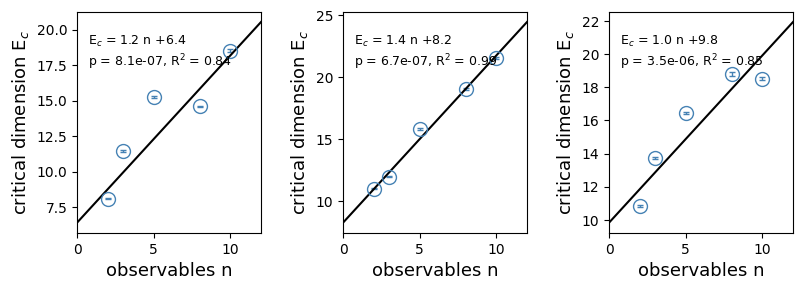

In [15]:
n_obs = 20
fig,axes= plt.subplots(1,3,figsize=(8,3))
for j,model_index in enumerate([1, 2, 3]):
    ax = axes[j]
    data = np.loadtxt(f"./saved_data/Ec_sparse_model{model_index}_nobs{n_obs}.txt")
    # Extract x, y, and CI bounds
    N_TG = data[0,:]
    Ec = data[1,:]
    Ec_se = data[2,:]
    ax.errorbar(N_TG,Ec,Ec_se,marker="o",c='steelblue',mfc="None",capsize=2,lw=0,markersize=10,
                    elinewidth=1)

    # Weighted fit using standard errors
    popt, pcov = curve_fit(linear_model, N_TG, Ec, sigma=Ec_se, absolute_sigma=True)
    slope, intercept = popt
    slope_se, intercept_se = np.sqrt(np.diag(pcov))

    # residuals and total sums of squares
    y_pred = linear_model(N_TG, slope, intercept)
    SS_res = np.sum(((Ec - y_pred)/Ec_se)**2)     # weighted residual SS
    SS_tot = np.sum(((Ec - np.average(Ec, weights=1/Ec_se**2))/Ec_se)**2)

    R2 = 1 - SS_res / SS_tot

    # Compute t-statistic and p-value
    dof = len(N_TG) - 2
    t_stat = slope / slope_se
    p_value = 2 * (1 - t.cdf(np.abs(t_stat), df=dof))

    # Generate fit line and CI band
    x_fit = np.linspace(0, 12, 100)
    y_fit = linear_model(x_fit, slope, intercept)

    ax.plot(x_fit,y_fit,c="k")
    ax.set_xlim([0, 12])

    # ----- formatted report ---------------------------------------------------
    print(f"sparse case, n_obs={n_obs}")
    report = (
        f"Slope            : {slope:.3f} ± {slope_se:.3f} (SE)\n"
        f"Intercept        : {intercept:.3f} ± {intercept_se:.3f} (SE)\n"
        f"t-statistic      : {t_stat:.2f}  (dof = {dof})\n"
        f"p-value (slope≠0): {p_value:.3g}\n"
        f"Weighted R²      : {R2:.3f}"
    )

    print(report)

    # Format regression equation
    txt = (f"E$_c$ = {slope:.1f} n {intercept:+.1f}\n"
    f"p = {p_value:.1e}, R$^2$ = {R2:.2f}")
    ax.text(x=0.06, y=0.9, s=txt, va='top',transform=ax.transAxes, fontsize=9)
    ax.set_xlabel("observables n", fontsize=13)
    ax.set_ylabel("critical dimension E$_c$", fontsize=13)
fig.tight_layout()